In [6]:
import pandas as pd
import glob

In [7]:
# Use glob to get all CSV file paths
file_paths = glob.glob('F:\\geodata\\et_dataset_chenhuiling\\Daily\\zonal_mean_df*.csv')

# Create an empty list to store DataFrames
dataframes = []

# Iterate over each file path
for file_path in file_paths:
    # Read the CSV file
    df = pd.read_csv(file_path)
    
    # Extract the year from the file name
    year = file_path.split('zonal_mean_df')[1].split('.')[0]
    print(year)
    print(df.head())
    
    # Add the year column
    df['year'] = int(year)
    
    # Append the DataFrame to the list
    dataframes.append(df)

# Concatenate all DataFrames
combined_df = pd.concat(dataframes, ignore_index=True)

# Display the combined DataFrame
print(combined_df)


1999
         time       dsk  hsg         kq     slglk  tgzlk       wlwt        xhl
0  1982-01-01  1.500000  0.0  19.293103  7.965517  17.38  11.015873  14.600000
1  1982-01-02  1.416667  0.0  15.775862  5.310345  10.70   9.301587  13.733333
2  1982-01-03  2.166667  0.0  19.137931  6.034483  11.86   9.730159  19.066667
3  1982-01-04  2.583333  1.0  17.689655  5.655172  22.94  16.761905  21.533333
4  1982-01-05  3.375000  6.0  14.310345  7.137931  12.32  10.365079  23.666667
2000
         time       dsk   hsg         kq     slglk  tgzlk      wlwt        xhl
0  2000-01-01  3.708333  10.0  17.379310  8.206897  10.88  5.285714  21.600000
1  2000-01-02  3.333333   5.0  18.258621  9.137931  10.68  5.730159  32.666667
2  2000-01-03  2.500000   5.0  16.241379  7.862069  10.10  4.984127  32.333333
3  2000-01-04  1.666667   4.0  13.896552  8.344828   8.98  4.142857  23.266667
4  2000-01-05  3.583333   2.0  14.293103  8.068966   8.28  3.936508  16.666667
2001
         time       dsk  hsg         

In [8]:
# Convert 'time' column to datetime to extract month and day
combined_df['time'] = pd.to_datetime(combined_df['time'])

# Create a new 'full_date' column using year from 'year' and month/day from 'time'
combined_df['full_date'] = pd.to_datetime(combined_df['year'].astype(str) + '-' + combined_df['time'].dt.strftime('%m-%d'))

combined_df['time'] = combined_df['full_date']
combined_df.drop(['full_date','year'], axis=1, inplace=True)
combined_df.set_index('time', inplace=True)

<Axes: xlabel='time'>

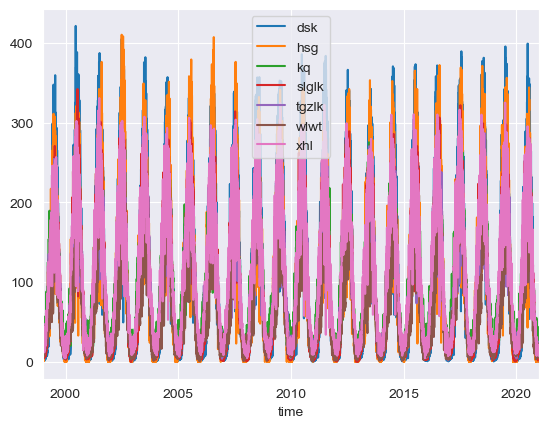

In [9]:
combined_df.plot()

In [10]:
combined_df.to_csv(r'F:\geodata\et_dataset_chenhuiling\et_dataset_yang_station.csv')